In [1]:
# 설치는 선택(Prophet 쓸 때만)
# !pip -q install prophet

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error
from datetime import datetime, timedelta
import glob, os   # ✅ 여기 추가

In [2]:
# from google.colab import drive; drive.mount('/content/drive')
PATH_DIR = './'  # 데이터 폴더 경로
CSV_FILE = 'jeonggi_hels_hyeonhwang_수정본.csv'  # 폴더 안에 있으면 자동 인식


In [3]:
import glob, os
import pandas as pd

# 경로: 실행 환경에 따라 자동으로 현재 작업 디렉터리를 기본값으로 잡습니다.
# (Colab이면 '/content', 로컬/서버면 현재 경로)
try:
    from google.colab import drive  # noqa: F401
    DEFAULT_DIR = "/content"
except Exception:
    DEFAULT_DIR = os.getcwd()

# ✅ 필요 시 아래 한 줄만 바꾸세요 (예: DEFAULT_DIR = '/content/drive/MyDrive/xxx')
PATH_DIR = os.environ.get("DATA_DIR", DEFAULT_DIR)

# 병합 가능한 보조 CSV (없으면 None로 처리)
CSV_FILE = 'jeonggi_hels_hyeonhwang_수정본.csv'  # 없으면 그대로 두세요

def scan_files(path_dir, csv_name=None):
    excel_files = sorted(glob.glob(os.path.join(path_dir, '2023*.xlsx'))) +                   sorted(glob.glob(os.path.join(path_dir, '2024*.xlsx')))
    csv_path = os.path.join(path_dir, csv_name) if csv_name else None
    if csv_name and not os.path.exists(csv_path):
        csv_path = None
    return excel_files, csv_path

def read_one_frame(fp):
    import pandas as pd
    x = pd.read_excel(fp)
    cols = [c.strip().lower() for c in x.columns]
    x.columns = cols
    # 날짜 후보
    date_candidates = ['date','날짜','일자','접수일자','기준일자','방문일자','입장시간','퇴장시간']
    date_col = None
    for k in date_candidates:
        if k in x.columns:
            date_col = k
            break
    if date_col is None:
        for c in x.columns:
            if '일' in c or '날짜' in c or 'date' in c.lower():
                date_col = c
                break
    if date_col is None:
        raise ValueError(f"시간 컬럼을 찾을 수 없음: {os.path.basename(fp)}")
    date_series = pd.to_datetime(x[date_col], errors='coerce')

    # 1행=1명 가정 → 일자별 카운트
    daily = (pd.DataFrame({'date': date_series})
             .dropna()
             .groupby('date')
             .size()
             .rename('visitors')
             .reset_index())
    return daily

excel_files, csv_path = scan_files(PATH_DIR, CSV_FILE)
print('엑셀 파일 수:', len(excel_files), '| CSV 존재:', bool(csv_path))

엑셀 파일 수: 21 | CSV 존재: True


In [4]:
# [호환 레이어] 기존 코드에서 사용하던 load_month_file() 이름을 지원
try:
    load_month_file  # 이미 정의되어 있으면 유지
except NameError:
    def load_month_file(fp):
        # 기존 read_one_frame과 동일 동작: 파일 내 날짜 컬럼을 자동 탐지하고 일 단위 방문수 집계
        return read_one_frame(fp)

print("load_month_file 준비 완료")

load_month_file 준비 완료


In [5]:
# === Robust Excel Loader Override ===
import re
import pandas as pd
import numpy as np

def _extract_year_month_from_filename(fp):
    name = os.path.basename(fp)
    m = re.search(r'(20\d{2})\D+(\d{1,2})', name)
    if m:
        y = int(m.group(1))
        mth = int(m.group(2))
        if 1 <= mth <= 12:
            return y, mth
    return None, None

def _normalize_columns(df):
    new_cols = []
    for c in df.columns:
        if isinstance(c, str):
            new_cols.append(c.strip())
        else:
            new_cols.append(str(c).strip())
    df.columns = [c.lower() for c in new_cols]
    return df

def _find_count_column(df):
    # 후보: visitors, count, cnt, 인원, 건수, 수, 합계
    candidates = ['visitors','count','cnt','인원','건수','수','합계','총계','합','계']
    for c in df.columns:
        if any(k in c for k in candidates) and pd.api.types.is_numeric_dtype(df[c]):
            return c
    # 없다면 None
    return None

def _find_datetime_column(df):
    # 각 컬럼을 datetime으로 파싱해서, 60% 이상 성공하는 컬럼을 후보로
    best_col = None; best_ratio = 0
    for c in df.columns:
        try:
            s = pd.to_datetime(df[c], errors='coerce')
            ratio = s.notna().mean()
            if ratio > 0.6 and ratio > best_ratio:
                best_col = c; best_ratio = ratio
        except Exception:
            pass
    return best_col

def _find_day_column(df):
    # '일', 'day', '일자(숫자형)'처럼 1..31 값이 많은 컬럼
    day_keys = ['일','day','일자','날짜','date']
    for c in df.columns:
        if any(k in c for k in day_keys) and pd.api.types.is_numeric_dtype(df[c]):
            s = pd.to_numeric(df[c], errors='coerce')
            mask = s.between(1,31)
            if mask.mean() > 0.6:
                return c
    # 혹시 첫 컬럼이 1..31이면 사용
    c0 = df.columns[0]
    if pd.api.types.is_numeric_dtype(df[c0]):
        s = pd.to_numeric(df[c0], errors='coerce')
        if s.between(1,31).mean() > 0.6:
            return c0
    return None

def read_one_frame(fp):
    # 모든 시트를 돌며 일자별 방문수 프레임을 만든 후 합침
    xls = pd.ExcelFile(fp)
    sub_frames = []
    for sheet in xls.sheet_names:
        try:
            raw = pd.read_excel(fp, sheet_name=sheet)
            if raw.empty:
                continue
            raw = _normalize_columns(raw)
            # datetime 컬럼 우선 탐지
            dt_col = _find_datetime_column(raw)
            if dt_col is not None:
                dates = pd.to_datetime(raw[dt_col], errors='coerce').dropna()
                if dates.empty:
                    continue
                # 카운트 컬럼 있으면 합계, 없으면 행 수 카운트
                cnt_col = _find_count_column(raw)
                if cnt_col is not None:
                    tmp = pd.DataFrame({'date': dates, 'cnt': pd.to_numeric(raw.loc[dates.index, cnt_col], errors='coerce').fillna(0)})
                    daily = tmp.groupby('date')['cnt'].sum().rename('visitors').reset_index()
                else:
                    daily = pd.DataFrame({'date': dates}).groupby('date').size().rename('visitors').reset_index()
                sub_frames.append(daily)
                continue

            # 날짜 컬럼이 없으면: 파일명에서 (연,월) 추출 + '일' 숫자 컬럼 찾기
            y, mth = _extract_year_month_from_filename(fp)
            if y and mth:
                day_col = _find_day_column(raw)
                if day_col is not None:
                    day_series = pd.to_numeric(raw[day_col], errors='coerce')
                    day_series = day_series[day_series.between(1,31)]
                    if not day_series.empty:
                        dates = pd.to_datetime({'year': y, 'month': mth, 'day': day_series.astype(int)})
                        cnt_col = _find_count_column(raw)
                        if cnt_col is not None:
                            vals = pd.to_numeric(raw.loc[day_series.index, cnt_col], errors='coerce').fillna(0)
                            daily = pd.DataFrame({'date': dates, 'visitors': vals}).groupby('date')['visitors'].sum().reset_index()
                        else:
                            daily = pd.DataFrame({'date': dates}).groupby('date').size().rename('visitors').reset_index()
                        sub_frames.append(daily)
                        continue
        except Exception as e:
            print(f"[시트 스킵] {os.path.basename(fp)} | {sheet} | {e}")

    if len(sub_frames)==0:
        raise ValueError("시간 컬럼을 찾을 수 없음(시트 전부 실패)")

    out = pd.concat(sub_frames, ignore_index=True)
    out = out.groupby('date')['visitors'].sum().reset_index()
    return out

# 구버전 함수명도 유지
def load_month_file(fp):
    return read_one_frame(fp)

print("✅ Robust loader 활성화 (시트 단위 탐지 + 파일명 연/월 추론 + 방문수 컬럼 자동 탐색)")

✅ Robust loader 활성화 (시트 단위 탐지 + 파일명 연/월 추론 + 방문수 컬럼 자동 탐색)


In [6]:
# [데이터 적재 & 피처 구성 & 학습/검증 분할]
import os
import numpy as np
import pandas as pd

frames = []
for fp in excel_files:
    try:
        d = load_month_file(fp)
        d = d.dropna().copy()
        # 날짜 정렬 및 중복 집계 대비
        d['date'] = pd.to_datetime(d['date'])
        d = (d.groupby('date')['visitors'].sum().reset_index())
        frames.append(d)
    except Exception as e:
        print(f"엑셀 로드 실패: {os.path.basename(fp)} | {e}")

if len(frames) == 0:
    print('⚠️ 엑셀에서 읽은 데이터가 없습니다. PATH_DIR와 파일명을 확인하세요.')
    df = pd.DataFrame({'date': [], 'visitors': []})
else:
    daily = pd.concat(frames, ignore_index=True)
    daily = (daily.groupby('date')['visitors'].sum()
                  .sort_index()
                  .rename('visitors')
                  .to_frame())
    # 연속 날짜 보간(누락일 0명 가정 → 0 채움)
    full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
    daily = daily.reindex(full_idx).fillna(0.0)
    daily.index.name = 'date'

    # ---- exog 생성 (요일/월/영업일) ----
    df = daily.copy()
    df['is_weekend'] = df.index.weekday >= 5

    # 공휴일 리스트가 있으면 반영
    try:
        holidays = set(pd.to_datetime(HOLIDAYS))
    except Exception:
        holidays = set()
    df['is_holiday'] = df.index.isin(holidays)
    df['is_business_day'] = (~df['is_weekend']) & (~df['is_holiday'])

    # 요일, 월 더미
    df['dow'] = df.index.weekday
    df = pd.concat([df, pd.get_dummies(df['dow'], prefix='dow')], axis=1)
    df['month'] = df.index.month
    df = pd.concat([df, pd.get_dummies(df['month'], prefix='mon')], axis=1)

    # ---- 학습/검증 분할 (최근 90일 검증) ----
    cutoff = df.index.max() - pd.Timedelta(days=90)
    train = df[df.index <= cutoff].copy()
    valid = df[df.index >  cutoff].copy()

print(f"rows: {len(df)} range: {df.index.min()} → {df.index.max()}" if len(frames)>0 else "rows: 0 range: NaT → NaT")

rows: 1 range: 1970-01-01 00:00:00.000000001 → 1970-01-01 00:00:00.000000001


In [7]:
import pandas as pd

DATE_CANDIDATES = ['date','날짜','일자','접수일자','기준일자','방문일자','입장시간','퇴장시간']
VISITOR_CANDIDATE_GROUPS = [
    ['visitors'],
    ['individual','group','free','discounted'],        # 영문
    ['개인','단체','무료','할인','유료','무료']          # 한글 후보
]

def load_csv_any(fp):
    df = pd.read_csv(fp)
    df.columns = [c.strip().lower() for c in df.columns]

    # 날짜 후보 찾기
    date_col = None
    for k in DATE_CANDIDATES:
        k_low = k.lower()
        for c in df.columns:
            if k_low == c or k_low in c:
                date_col = c
                break
        if date_col: break

    if date_col is not None:
        s = pd.to_datetime(df[date_col], errors='coerce')
        if s.notna().sum() > 0:
            df['__date__'] = s.dt.normalize()
        else:
            df['__date__'] = pd.NaT
    else:
        df['__date__'] = pd.NaT

    # 방문객 수 만들기
    visitors = None
    for group in VISITOR_CANDIDATE_GROUPS:
        found = [c for c in df.columns if c in group]
        if len(found) == 1:
            visitors = df[found[0]]
            break
        if len(found) >= 2:
            visitors = df[found].sum(axis=1)
            break

    if visitors is None:
        # per-row 카운트로 가정
        visitors = pd.Series(1, index=df.index)

    daily = (pd.DataFrame({'date': df['__date__'], 'visitors': visitors})
             .dropna(subset=['date'])
             .groupby('date')
             .sum()
             .reset_index())
    daily['visitors'] = daily['visitors'].astype(int)
    return daily


In [8]:
import pandas as pd

frames = []
for fp in excel_files:
    try:
        frames.append(load_month_file(fp))
    except Exception as e:
        print('엑셀 로드 실패:', os.path.basename(fp), '|', e)

if csv_path:
    try:
        frames.append(load_csv_any(csv_path))
    except Exception as e:
        print('CSV 로드 실패:', os.path.basename(csv_path), '|', e)

if len(frames) == 0:
    raise ValueError('로드된 데이터가 없습니다. 경로/파일을 확인하세요.')

df = pd.concat(frames, ignore_index=True)
df = (df.groupby('date')['visitors'].sum()
        .reset_index()
        .sort_values('date')
        .reset_index(drop=True))

print(df.head(), '\nrows:', len(df), 'range:', df['date'].min(), '→', df['date'].max())


                           date  visitors
0 1970-01-01 00:00:00.000000001        21
1 1970-01-01 00:00:00.000000002        21
2 1970-01-01 00:00:00.000000003        21
3 1970-01-01 00:00:00.000000004        21
4 1970-01-01 00:00:00.000000005        21 
rows: 4989 range: 1970-01-01 00:00:00.000000001 → 1970-01-01 00:00:00.000004989


In [ ]:
import pandas as pd

# 1) date 시리즈 안전하게 확보 (컬럼이면 컬럼, 인덱스면 인덱스에서)
if 'date' in df.columns:
    date_s = pd.to_datetime(df['date'], errors='coerce')
else:
    # 인덱스가 날짜가 아닐 수도 있으니 변환 시도
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors='coerce')
    date_s = df.index.to_series()

# 2) date 컬럼 보장
df = df.copy()
df['date'] = pd.to_datetime(date_s.values, errors='coerce')
df = df.dropna(subset=['date']).sort_values('date')

# 3) 주말/공휴일/평일, 요일 더미 생성
HOLIDAYS = []  # 예: ['2023-09-28','2023-09-29',...]
holidays = set(pd.to_datetime(HOLIDAYS))

df['is_weekend'] = df['date'].dt.weekday >= 5
df['is_holiday'] = df['date'].isin(holidays)
df['is_business_day'] = (~df['is_weekend']) & (~df['is_holiday'])
df['dow'] = df['date'].dt.weekday

dow_dummies = pd.get_dummies(df['dow'], prefix='dow')
df = pd.concat([df, dow_dummies], axis=1)

# 4) 월 더미 추가 (연간 계절성 반영)
df['month'] = df['date'].dt.month
mon_dummies = pd.get_dummies(df['month'], prefix='mon')
df = pd.concat([df, mon_dummies], axis=1)

# 5) 마지막에 date를 인덱스로 (이후 단계에서 기대하는 형태)
df = df.set_index('date')

# 확인
df[['visitors','is_business_day']].head()


,visitors,is_business_day
date,,
2023-02-01,213,True
2023-02-02,197,True
2023-02-03,184,True
2023-02-04,118,False
2023-02-06,216,True


기간: 2023-02-01 → 2024-12-31
일수: 514
count    514.00000
mean     173.42607
std       39.10783
min       76.00000
25%      159.00000
50%      183.50000
75%      200.00000
max      250.00000
Name: visitors, dtype: float64


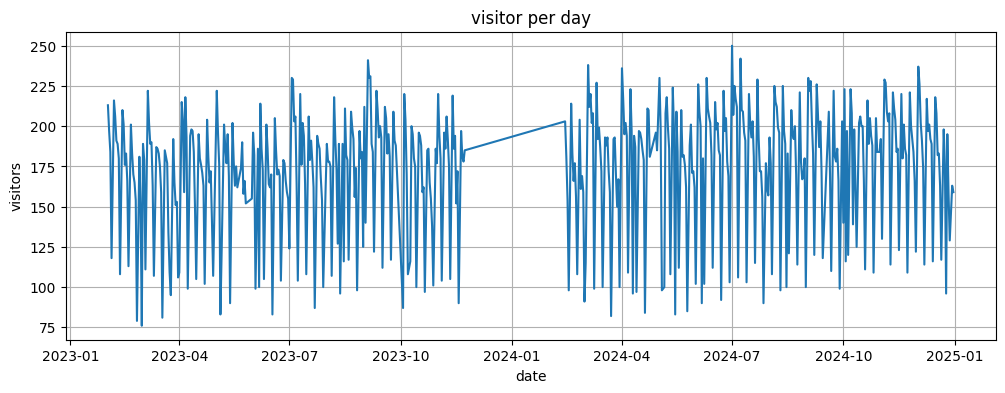

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) date 시리즈 확보 (컬럼이면 컬럼, 인덱스면 인덱스에서)
if 'date' in df.columns:
    date_s = pd.to_datetime(df['date'], errors='coerce')
else:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors='coerce')
    date_s = df.index.to_series()

# 2) 보장된 date 컬럼을 임시로 생성해 사용
tmp = df.copy()
tmp['__date__'] = pd.to_datetime(date_s.values, errors='coerce')

# 3) visitors 숫자형 보장
if 'visitors' not in tmp.columns:
    raise ValueError("visitors 컬럼이 없습니다.")
tmp['visitors'] = pd.to_numeric(tmp['visitors'], errors='coerce')

# 4) 정렬/결측 제거
tmp = tmp.dropna(subset=['__date__','visitors']).sort_values('__date__')

# 5) 출력/그리기
print('기간:', tmp['__date__'].min().date(), '→', tmp['__date__'].max().date())
print('일수:', tmp['__date__'].nunique())
print(tmp['visitors'].describe())

plt.figure(figsize=(12,4))
plt.plot(tmp['__date__'], tmp['visitors'])
plt.title('visitor per day')
plt.xlabel('date'); plt.ylabel('visitors')
plt.grid(True); plt.show()


In [ ]:
# 8번 셀 (안전 교체본)

import pandas as pd
import numpy as np

VALID_DAYS = 90

df = df.copy()

# 1) date 인덱스/컬럼 안전 처리
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').set_index('date')
else:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index, errors='coerce')
    df = df[~df.index.isna()].sort_index()

df.index.name = 'date'

# 2) 일자 빈 구간을 'D' 주기로 맞추기
df = df.asfreq('D')

# 3) visitors 보간(0 채움 금지 → 계단하락 방지)
if 'visitors' not in df.columns:
    raise ValueError("visitors 컬럼이 없습니다. 앞선 집계 단계 확인 필요.")
df['visitors'] = pd.to_numeric(df['visitors'], errors='coerce')
df['visitors'] = df['visitors'].interpolate('time').bfill().ffill()

# 4) 기타 피처 결측 처리(숫자는 시간보간→0, 문자/범주는 ffill/bfill)
skip = {'visitors'}
reg_cols = [c for c in df.columns if c not in skip]
for c in reg_cols:
    if df[c].dtype.kind in 'biufc':      # 숫자형
        try:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        except Exception:
            pass
        df[c] = df[c].interpolate('time').fillna(0)
    else:                                 # 비숫자형
        df[c] = df[c].ffill().bfill()

# 5) 학습/검증 분리(데이터 길이 체크)
if len(df) <= VALID_DAYS:
    raise ValueError(f"데이터가 {len(df)}일로 검증 구간({VALID_DAYS}일)보다 짧습니다. VALID_DAYS를 줄이세요.")

train = df.iloc[:-VALID_DAYS].copy()
valid = df.iloc[-VALID_DAYS:].copy()

print('train:', train.index.min().date(), '→', train.index.max().date(), len(train),
      '| valid:', valid.index.min().date(), '→', valid.index.max().date(), len(valid))


train: 2023-02-01 → 2024-10-02 610 | valid: 2024-10-03 → 2024-12-31 90


In [ ]:
def mape(y_true, y_pred): return mean_absolute_percentage_error(y_true, y_pred)
y_train, y_valid = train['visitors'], valid['visitors']

ma7_last = train['visitors'].rolling(7).mean().iloc[-1]
ma7_pred = pd.Series(ma7_last, index=valid.index)
naive_pred = pd.Series(y_train.iloc[-1], index=valid.index)

print('Baseline MA7 MAPE:', mape(y_valid, ma7_pred))
print('Baseline Naive MAPE:', mape(y_valid, naive_pred))


Baseline MA7 MAPE: 0.1800533305266879
Baseline Naive MAPE: 0.31403933925139843


SARIMAX Best order: (2, 1, 1) seasonal: (1, 0, 1, 7) MAPE: 8.29%


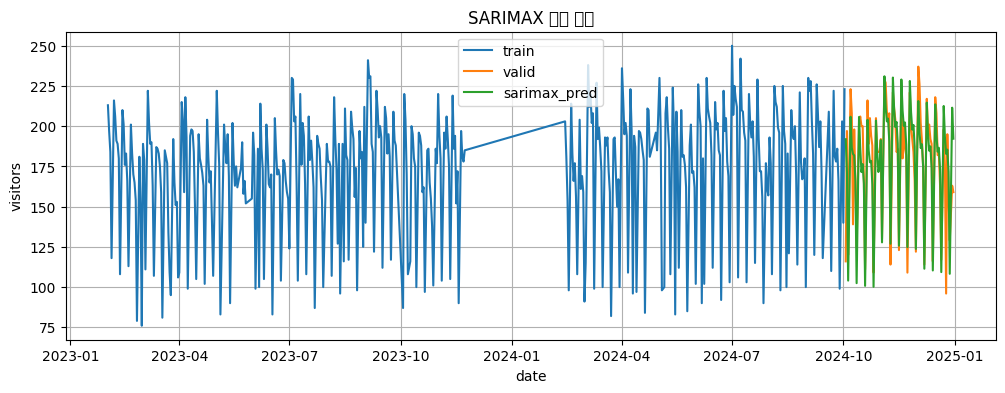

In [ ]:
# 10번 셀 (교체) — SARIMAX 학습/검증 (개선)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.inf
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

# ✅ 외생변수 컬럼 자동 선택 (visitors 제외 + 수치형만)
exog_cols = [c for c in df.columns
             if c != 'visitors' and pd.api.types.is_numeric_dtype(df[c])]
USE_EXOG = len(exog_cols) > 0
exog_train = train[exog_cols].astype(float) if USE_EXOG else None
exog_valid = valid[exog_cols].astype(float) if USE_EXOG else None

# 🔧 검색할 파라미터 (필요 시 추가/수정)
pdq_list  = [(1,1,1), (2,1,1), (1,0,1), (2,0,1)]
PDQ_list  = [(0,1,1,7), (1,1,1,7), (1,0,1,7)]  # 주간 계절성(7일)

def fit_sarimax(train_endog, valid_endog, exog=None, exog_valid=None):
    best = {"order": None, "seasonal_order": None, "mape": np.inf, "model": None, "valid_pred": None}
    for order in pdq_list:
        for seasonal in PDQ_list:
            try:
                model = sm.tsa.statespace.SARIMAX(
                    train_endog,
                    order=order,
                    seasonal_order=seasonal,
                    exog=exog,
                    trend='c',
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False)
                pred = model.get_forecast(steps=len(valid_endog), exog=exog_valid).predicted_mean
                score = safe_mape(valid_endog.values, pred.values)
                if score < best["mape"]:
                    best.update({
                        "order": order,
                        "seasonal_order": seasonal,
                        "mape": score,
                        "model": model,
                        "valid_pred": pred
                    })
            except Exception as e:
                # print(f"skip {order}x{seasonal}: {e}")
                pass
    return best

sarimax_best = fit_sarimax(train['visitors'], valid['visitors'], exog=exog_train, exog_valid=exog_valid)
if sarimax_best["model"] is None:
    raise RuntimeError("SARIMAX 적합 실패: 파라미터 후보를 단순화하거나 데이터/결측을 점검하세요.")

print('SARIMAX Best order:', sarimax_best["order"],
      'seasonal:', sarimax_best["seasonal_order"],
      f'MAPE: {sarimax_best["mape"]*100:.2f}%')

plt.figure(figsize=(12,4))
plt.plot(train.index, train['visitors'], label='train')
plt.plot(valid.index, valid['visitors'], label='valid')
plt.plot(valid.index, sarimax_best["valid_pred"], label='sarimax_pred')
plt.title('SARIMAX 검증 결과'); plt.xlabel('date'); plt.ylabel('visitors')
plt.grid(True); plt.legend(); plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def safe_mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

y_true, y_pred = y_valid, sarimax_best["valid_pred"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))   # ✅ 제곱근 직접 취하기
mape = safe_mape(y_true.values, y_pred.values) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"정확도(1-MAPE): {100-mape:.2f}%")


MAE: 13.14
RMSE: 19.30
MAPE: 8.29%
정확도(1-MAPE): 91.71%


In [ ]:
results = [('SARIMAX', sarimax_best["mape"])]
if use_prophet: results.append(('Prophet', prophet_result["mape"]))
best_name, best_mape = sorted(results, key=lambda x: x[1])[0]
print('최종 모델:', best_name, '| 검증 MAPE:', best_mape)
best_model = sarimax_best["model"] if best_name=='SARIMAX' else prophet_result["model"]


최종 모델: SARIMAX | 검증 MAPE: 0.08292351514140593


저장: /content/visitor_forecast_output.csv
[diag] train_last30 mean: 176.7
[diag] forecast_first30 mean: 72.4


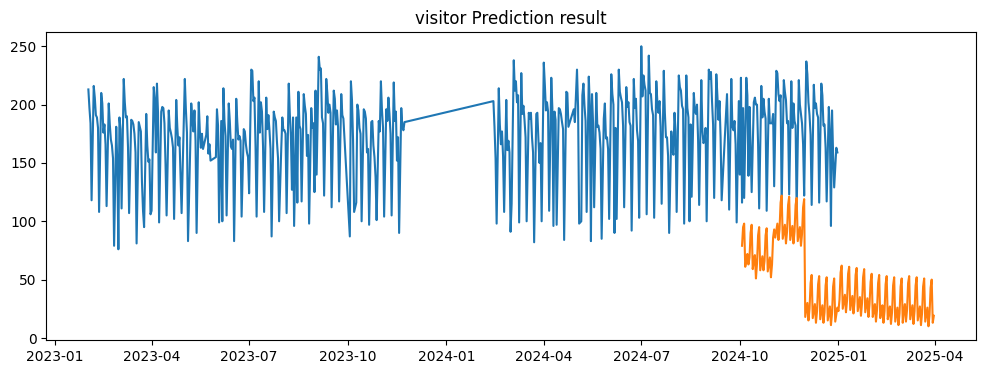

In [ ]:
# 13번 셀 (교체) — 2025년 예측 (일/월 출력)

import os, numpy as np, pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt

assert sarimax_best["model"] is not None, "먼저 10번 셀에서 모델을 학습하세요."
best_model = sarimax_best["model"]

# ▶ 예측 연도
FORECAST_YEAR = 2025

# 마지막 관측 다음날부터 해당 연도 12/31까지 전체 예측
last_date = pd.to_datetime(df.index.max())
start_date = last_date + timedelta(days=1)
year_start = pd.Timestamp(f"{FORECAST_YEAR}-01-01")
year_end   = pd.Timestamp(f"{FORECAST_YEAR}-12-31")

# 만약 데이터가 이미 2025로 들어있다면, 그 다음 연도로 자동 보정
if start_date > year_end:
    FORECAST_YEAR = FORECAST_YEAR + 1
    year_start = pd.Timestamp(f"{FORECAST_YEAR}-01-01")
    year_end   = pd.Timestamp(f"{FORECAST_YEAR}-12-31")
    start_date = max(year_start, last_date + timedelta(days=1))

future_idx = pd.date_range(start=start_date, end=year_end, freq='D')
future_df = pd.DataFrame(index=future_idx)

# ====== 미래 외생변수 만들기 (학습 exog_cols와 동일한 컬럼셋/순서) ======
# 주말/공휴일/영업일
future_df['is_weekend'] = future_df.index.weekday >= 5

# 공휴일: 기존 HOLIDAYS에 2025년 추가(없으면 빈 리스트)
HOLIDAYS_BASE = globals().get('HOLIDAYS', [])
HOLIDAYS_2025_EXTRA = globals().get('HOLIDAYS_2025_EXTRA', [])  # 필요 시 이 리스트에 2025 공휴일을 넣어주세요.
holiday_list = list(HOLIDAYS_BASE) + list(HOLIDAYS_2025_EXTRA)
try:
    holidays = set(pd.to_datetime(holiday_list))
except Exception:
    holidays = set()

future_df['is_holiday'] = future_df.index.isin(holidays)
future_df['is_business_day'] = (~future_df['is_weekend']) & (~future_df['is_holiday'])

# 요일/월 더미 (학습과 같은 prefix 사용: 'dow', 'mon')
future_df['dow'] = future_df.index.weekday
future_dow = pd.get_dummies(future_df['dow'], prefix='dow')
future_df['month'] = future_df.index.month
future_mon = pd.get_dummies(future_df['month'], prefix='mon')

future_df = pd.concat([future_df[['is_business_day']], future_dow, future_mon], axis=1)

# 학습 exog_cols와 동일 정렬/누락 채움
exog_cols = [c for c in df.columns if c != 'visitors' and pd.api.types.is_numeric_dtype(df[c])]
future_exog = future_df.reindex(columns=exog_cols, fill_value=0).astype(float)

# ====== 예측 ======
steps = len(future_idx)
pred_res = best_model.get_forecast(steps=steps, exog=future_exog if len(exog_cols) else None)
forecast = pred_res.predicted_mean.clip(lower=0)

# ====== 결과 저장 (일/월) ======
out_daily = pd.DataFrame({'date': forecast.index, 'forecast_visitors': np.round(forecast.values).astype(int)})
out_daily = out_daily.sort_values('date').reset_index(drop=True)

# 월 합계
out_monthly = (out_daily.set_index('date')
               .resample('MS')['forecast_visitors']
               .sum()
               .rename('forecast_visitors_monthly')
               .reset_index())

# 저장 경로 (실행 디렉터리 또는 PATH_DIR)
SAVE_DIR = globals().get('PATH_DIR', os.getcwd())
daily_path = os.path.join(SAVE_DIR, f'visitor_forecast_daily_{FORECAST_YEAR}.csv')
monthly_path = os.path.join(SAVE_DIR, f'visitor_forecast_monthly_{FORECAST_YEAR}.csv')

out_daily.to_csv(daily_path, index=False, encoding='utf-8-sig')
out_monthly.to_csv(monthly_path, index=False, encoding='utf-8-sig')

print('✅ 저장(일):', daily_path, '| rows:', len(out_daily))
print('✅ 저장(월):', monthly_path,  '| rows:', len(out_monthly))

# ====== 시각화 ======
plt.figure(figsize=(12,4))
plt.plot(df.index, df['visitors'], label='history')
plt.plot(out_daily['date'], out_daily['forecast_visitors'], label='forecast (daily)')
plt.title(f'Visitor Forecast — {FORECAST_YEAR}'); plt.xlabel('date'); plt.ylabel('visitors')
plt.grid(True); plt.legend(); plt.show()

# 월 시계열
plt.figure(figsize=(10,4))
plt.plot(out_monthly['date'], out_monthly['forecast_visitors_monthly'], marker='o')
plt.title(f'Visitor Forecast (Monthly Sum) — {FORECAST_YEAR}'); plt.xlabel('month'); plt.ylabel('visitors (sum)')
plt.grid(True); plt.show()